# Regime-Conditional Monte Carlo

Historical backtests give us one path. The honest question is what the *distribution* of paths could have looked like, particularly across regimes that the historical sample under-samples. We approach this in three steps:

1. Fit a two-state Gaussian HMM on SPY returns and identify regimes (loosely interpretable as bull and bear).
2. Use the Viterbi-decoded state sequence to label each historical day.
3. Simulate forward paths by drawing regime sequences from the fitted transition matrix and bootstrapping strategy returns *conditional on regime*. The result is a distribution over forward-year Sharpe, max drawdown, and terminal wealth that respects the regime structure.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM

from helper import port_ret

rng = np.random.default_rng(7)
pd.set_option('display.float_format', '{:.4f}'.format)


## Load Data

Strategy returns are reconstructed from the optimised in-sample weights of the combined three-signal portfolio. Run notebooks 01-04 first.


In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close = raw['Close']
returns = close.pct_change()
spy = pd.read_parquet('../data/spy.parquet')['Close'].squeeze().pct_change().dropna()

labels = ['01_mean_reversion', '02_momentum', '03_low_volatility']
weights = []
for stem in labels:
    w_is = pd.read_parquet(f'../data/weights_{stem}_is.parquet')
    w_oos = pd.read_parquet(f'../data/weights_{stem}_oos.parquet')
    w = pd.concat([w_is, w_oos]).sort_index()
    w = w[~w.index.duplicated(keep='last')]
    weights.append(w)

common_idx = weights[0].index
for w in weights[1:]:
    common_idx = common_idx.intersection(w.index)
common_cols = weights[0].columns
for w in weights[1:]:
    common_cols = common_cols.intersection(w.columns)

stack = np.stack([w.loc[common_idx, common_cols].values for w in weights])
w_combined = pd.DataFrame(stack.mean(axis=0), index=common_idx, columns=common_cols)
strat_ret = port_ret(w_combined, returns.reindex(common_idx)[common_cols], tcost_bps=5).dropna()
strat_ret.head()


Date
2006-01-10    0.0020
2006-01-11   -0.0021
2006-01-12    0.0029
2006-01-13    0.0017
2006-01-17    0.0052
dtype: float64

## Fit Two-State Gaussian HMM on SPY

We fit on SPY rather than the strategy itself because the regime concept is most naturally a property of the market, not of the strategy. The fitted states will identify periods of high mean / low volatility versus low mean / high volatility, which line up with what we usually call bull and bear.


In [3]:
spy_train = spy.loc['2005':'2020']
X_hmm = spy_train.values.reshape(-1, 1)

model = GaussianHMM(n_components=2, covariance_type='full',
                    n_iter=200, random_state=42)
model.fit(X_hmm)

means = model.means_.flatten()
vols = np.sqrt(model.covars_.flatten())
transmat = model.transmat_
stationary = model.get_stationary_distribution()

# Order states so that state 0 is bull (positive mean), state 1 is bear
if means[0] < means[1]:
    order = [1, 0]
    means = means[order]
    vols = vols[order]
    transmat = transmat[order][:, order]
    stationary = stationary[order]
    relabel = lambda s: 1 - s
else:
    relabel = lambda s: s

summary = pd.DataFrame({
    'state': ['bull', 'bear'],
    'daily_mean':  [f'{m*100:.3f}%' for m in means],
    'daily_vol':   [f'{v*100:.3f}%' for v in vols],
    'stationary':  [f'{s*100:.1f}%' for s in stationary],
})
summary


Model is not converging.  Current: 13086.964559584116 is not greater than 13087.043581238899. Delta is -0.07902165478299139


,state,daily_mean,daily_vol,stationary
0,bull,0.091%,0.711%,78.4%
1,bear,-0.126%,2.331%,21.6%


In [4]:
pd.DataFrame(transmat, index=['from_bull', 'from_bear'],
             columns=['to_bull', 'to_bear'])


,to_bull,to_bear
from_bull,0.9877,0.0123
from_bear,0.0446,0.9554


## Decode Historical Regimes

Viterbi gives the most likely state sequence given the observed returns. We use it to label every historical day so the bootstrap can sample strategy returns from the correct regime pool.


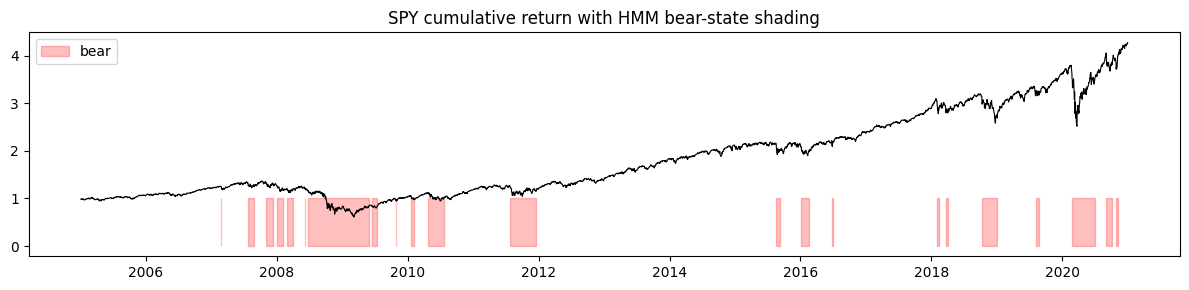

In [5]:
states_train = relabel(model.predict(X_hmm))
states_series = pd.Series(states_train, index=spy_train.index)

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(states_series.index, 0, 1, where=(states_series == 1),
                color='red', alpha=0.25, label='bear')
ax.plot((1 + spy_train).cumprod(), color='k', linewidth=0.8)
ax.set_title('SPY cumulative return with HMM bear-state shading')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Strategy Returns by Regime

Conditional means and volatilities of the strategy in each regime. If the strategy's profile shifts substantially across regimes, the unconditional Sharpe is concealing important variation.


In [6]:
joint = pd.concat([
    strat_ret.rename('strat'),
    states_series.reindex(strat_ret.index).rename('state')
], axis=1).dropna()

by_state = joint.groupby('state')['strat'].agg(
    mean_daily='mean', std_daily='std', count='count')
by_state['mean_annual'] = by_state['mean_daily'] * 252
by_state['vol_annual']  = by_state['std_daily'] * np.sqrt(252)
by_state['sharpe']      = by_state['mean_annual'] / by_state['vol_annual']
by_state.index = ['bull', 'bear']
by_state


,mean_daily,std_daily,count,mean_annual,vol_annual,sharpe
bull,-0.0004,0.0066,2971,-0.1116,0.1044,-1.0689
bear,-0.0003,0.0218,800,-0.0669,0.3466,-0.1931


## Forward Simulation

We simulate `n_paths` forward paths of length `horizon` trading days. Each path:

1. Draws an initial state from the stationary distribution.
2. Steps the state through the fitted transition matrix.
3. At each step, draws a strategy return by bootstrapping from the historical pool of strategy returns observed in that state.

Bootstrapping from the empirical conditional distribution preserves the actual fat tails of the strategy in each regime, which a Gaussian simulation would lose. The HMM provides the regime structure; the bootstrap provides the within-regime distribution.


In [7]:
n_paths = 5000
horizon = 252

pool_bull = joint[joint['state'] == 0]['strat'].values
pool_bear = joint[joint['state'] == 1]['strat'].values
pools = [pool_bull, pool_bear]

all_paths = np.zeros((n_paths, horizon))
regime_counts = np.zeros((n_paths, 2), dtype=int)

for i in range(n_paths):
    state = rng.choice(2, p=stationary)
    for t in range(horizon):
        all_paths[i, t] = rng.choice(pools[state])
        regime_counts[i, state] += 1
        state = rng.choice(2, p=transmat[state])

print(f'Simulated {n_paths} paths of length {horizon} days.')
print(f'Average bear-state share per path: {regime_counts[:, 1].mean() / horizon:.1%}')


Simulated 5000 paths of length 252 days.
Average bear-state share per path: 21.4%


## Distribution of Path Outcomes

For each simulated path, compute Sharpe, max drawdown, and terminal wealth. The empirical distributions across paths bracket what a single historical backtest cannot show on its own.


In [8]:
def path_stats(path):
    sharpe = path.mean() / path.std() * np.sqrt(252) if path.std() > 0 else 0
    cum = np.cumprod(1 + path)
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    return sharpe, dd.min(), cum[-1] - 1

results = np.array([path_stats(p) for p in all_paths])
results_df = pd.DataFrame(results, columns=['sharpe', 'max_dd', 'terminal_ret'])
results_df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])


,sharpe,max_dd,terminal_ret
count,5000.0000,5000.0000,5000.0000
mean,-0.6070,-0.2200,-0.0973
std,0.9994,0.0920,0.1660
min,-4.2548,-0.6412,-0.6427
5%,-2.2127,-0.3878,-0.3431
25%,-1.2758,-0.2789,-0.2066
50%,-0.6325,-0.2063,-0.1093
75%,0.0762,-0.1504,-0.0023
95%,1.0624,-0.0932,0.1983
max,2.9982,-0.0443,0.8962


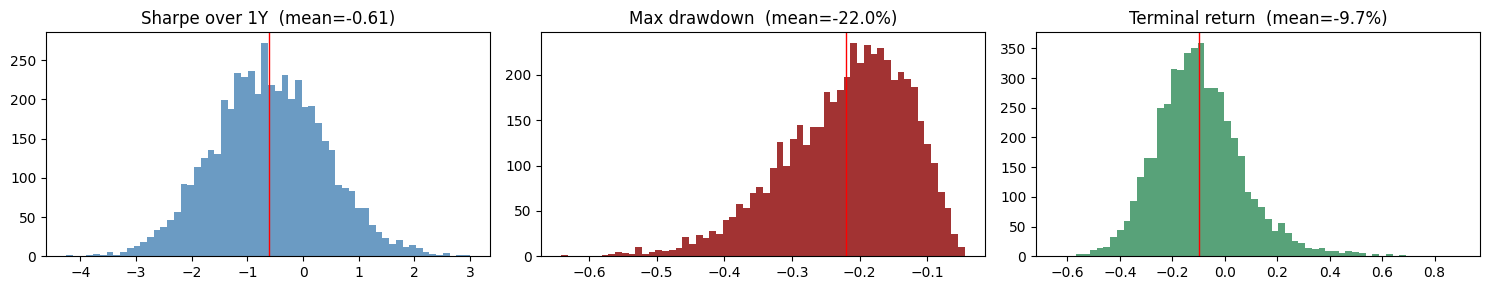

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].hist(results_df['sharpe'], bins=60, color='steelblue', alpha=0.8)
axes[0].axvline(results_df['sharpe'].mean(), color='red', linewidth=1)
axes[0].set_title(f"Sharpe over 1Y  (mean={results_df['sharpe'].mean():.2f})")

axes[1].hist(results_df['max_dd'], bins=60, color='darkred', alpha=0.8)
axes[1].axvline(results_df['max_dd'].mean(), color='red', linewidth=1)
axes[1].set_title(f"Max drawdown  (mean={results_df['max_dd'].mean()*100:.1f}%)")

axes[2].hist(results_df['terminal_ret'], bins=60, color='seagreen', alpha=0.8)
axes[2].axvline(results_df['terminal_ret'].mean(), color='red', linewidth=1)
axes[2].set_title(f"Terminal return  (mean={results_df['terminal_ret'].mean()*100:.1f}%)")
plt.tight_layout()
plt.show()


## Sensitivity to Bear-State Share

Conditional on the realised bear-state share in a given path, what does the forward Sharpe look like. The slope of this relationship is the regime sensitivity of the strategy.


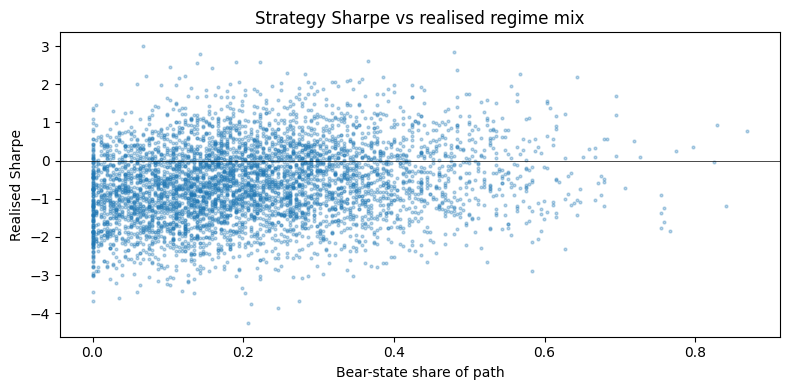

,mean,std,count
bear_bin,,,
"(-0.001, 0.0833]",-0.9272,0.9456,1035
"(0.0833, 0.155]",-0.7588,1.0080,975
"(0.155, 0.234]",-0.5283,0.9671,1024
"(0.234, 0.333]",-0.4422,0.9798,975
"(0.333, 0.869]",-0.3669,0.9893,991


In [10]:
bear_share = regime_counts[:, 1] / horizon
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(bear_share, results_df['sharpe'], s=4, alpha=0.3)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Bear-state share of path')
ax.set_ylabel('Realised Sharpe')
ax.set_title('Strategy Sharpe vs realised regime mix')
plt.tight_layout()
plt.show()

binned = pd.qcut(bear_share, 5)
results_df['bear_bin'] = binned
results_df.groupby('bear_bin', observed=True)['sharpe'].agg(['mean', 'std', 'count'])


## Interpretation and Caveats

The simulation gives an honest distribution over outcomes that a single historical backtest cannot. Two things are worth flagging.

First, the bootstrap assumes that within-regime daily returns are exchangeable. They are not, strictly: there is autocorrelation in volatility (GARCH effects) and in the strategy itself. A block bootstrap would preserve this dependence at the cost of needing a block-length choice; a parametric GARCH-conditional simulation would model it explicitly. We chose i.i.d. bootstrapping for clarity.

Second, the HMM is fitted on SPY and its regimes are interpretable as market states, not as strategy states. The strategy may have its own regime structure (driven by, say, dispersion or factor crowding) that is invisible to a SPY-fitted HMM. A more involved version of this analysis would fit a multivariate HMM on (SPY, dispersion, cross-sectional vol) and condition on the joint state.
